# 03 - Opportunity Analysis

## 1. Objectives

This notebook evaluates whether the observed lead-quality differences identified in the previous analysis can create a realistic opportunity to improve the overall Closed Rate.

The analysis focuses on:
- Establishing the current Closed Rate and the advertiser's 9.6% target.
- Quantifying the gap between current and target performance.
- Identifying segments with comparatively higher Closed Rates.
- Evaluating whether segment-level differences are large and substantial enough to influence overall lead quality.
- Modeling simple scenarios to estimate the potential impact of shifting the lead mix toward higher-quality segments.
- Translating the findings into practical opportunities for improving lead quality.

## 2. Importing Libraries

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
sns.set_theme(style="whitegrid")
pd.set_option("display.max_columns", None)
pd.set_option("display.float_format", "{:,.4f}".format)

## 3. Load the Dataset

In [2]:
df = pd.read_excel("../data/raw/Analyst_case_study_dataset_1_.xls")
df["IsClosed"] = df["CallStatus"].eq("Closed").astype(int)
print(f"Dataset shape: {df.shape[0]:,} rows × {df.shape[1]} columns")

Dataset shape: 3,021 rows × 25 columns


In [3]:
df.head()

,LeadCreated,FirstName,Email,VendorLeadID,CallStatus,WidgetName,PublisherZoneName,PublisherCampaignName,AddressScore,PhoneScore,AdvertiserCampaignName,State,DebtLevel,IP Address,Partner,ReferralDomain,MarketingCampaign,AdGroup,Keyword,SearchQuery,ReferralURL,ReferralURL Parameters,LandingPageURL,Landing Page URL Parameters,IsClosed
0,2009-07-01 01:24:29.563,Dorinda,kanani@sandwichisles.net,FDF81FDA-A649-437B-B99C-FDDE74F7971B,NaN,w-302252-DebtReduction1-1DC-CreditSolutions,TopLeft-302252,DebtReductionInc,NaN,5.0000,creditsolutions-branded-shortform,HI,30001-50000,NaN,google,www.google.com,Debt Holding Tank,Holding Tank - Debt,Debt specialists,debt specialists,http://www.google.com/search,sourceid=navclient&aq=1&oq=debt sp&ie=UTF-8&rl...,http://www.debtreductioninc.com/index8.html,utm_source=google&utm_medium=CPC&utm_content=H...,0
1,2009-04-13 15:27:35.990,Presetta,clerk2@ustconline.net,4190ACB7-5026-416C-B987-ED8AD427D5E6,NaN,w-300250-DebtReduction1-1DC-Head2,TopLeft-302252,DebtReductionInc,NaN,NaN,Debt Settlement1 Master,AL,90000-100000,NaN,AdKnowledge,NaN,Financial Services,Consolidate,NaN,NaN,NaN,NaN,http://www.debtreductioninc.com/index8.html,utm_source=AdKnowledge&utm_medium=CPC&utm_cont...,0
2,2009-04-21 07:22:59.000,Gina,wagoner_gina@yahoo.com,hFg80jf_R0CRN55hdhWILw,Unable to contact - Bad Contact Information,w-300250-DebtReduction1-1DC-Head2,TopLeft-302252,DebtReductionInc,NaN,NaN,Debt Settlement1 Master,NY,20001-30000,NaN,AdKnowledge,us.mc582.mail.yahoo.com,Financial Services,Consolidate,NaN,NaN,http://us.mc582.mail.yahoo.com/mc/showMessage,&fid=Inbox&sort=date&order=down&startMid=0&.ra...,http://www.debtreductioninc.com/index8.html,utm_source=AdKnowledge&utm_medium=CPC&utm_cont...,0
3,2009-08-03 19:39:02.000,Kari,usa4ley@yahoo.com,jB01QgYZxkWArI9jWxuufw,Contacted - Doesn't Qualify,w-302252-DebtReduction1-1DC-white,TopLeft-302252,DebtReductionInc,5.0000,3.0000,Debt Settlement1 Master,WA,20001-30000,NaN,Google,norwich.kijiji.com,DebtReductionInc,Lower Payments,NaN,NaN,http://norwich.kijiji.com/c-Cars-vehicles-Cars...,NaN,http://www.debtreductioninc.com/index12.html,utm_source=Google&utm_medium=cpc&utm_campaign=...,0
4,2009-04-13 10:18:37.490,Stephanie,sr1lambert@embarqmail.com,D5B32074-458E-40EC-B185-1FEF20AC626D,NaN,w-300250-DebtReduction1-1DC-BlueMeter,TopLeft-302252,DebtReductionInc,NaN,NaN,Debt Settlement1 Master,TX,More_than_100000,NaN,Google,NaN,DebtReductionInc,Debt Reduction,NaN,NaN,NaN,NaN,http://www.debtreductioninc.com/index8.html,utm_source=Google&utm_medium=cpc&utm_campaign=...,0


## 4. Baseline vs Target Quality

- The advertiser's stated target is to increase lead quality from approximately 8.0% to 9.6%, representing a **20% relative improvement** in Closed Rate.
- The dataset's actual baseline is slightly higher at 8.11%. Both figures are retained: 8.0% is the benchmark specified in the assignment, while 8.11% is the observed rate calculated from the data.

In [4]:
total_leads = len(df)
closed_leads = df["IsClosed"].sum()

In [5]:
observed_closed_rate = closed_leads / total_leads

In [6]:
assignment_baseline = 0.08
target_closed_rate = 0.096

In [7]:
opportunity_summary = pd.DataFrame({"Metric": ["Total Leads", "Closed Leads", "Observed Closed Rate", "Assignment Baseline", "Target Closed Rate"],
                                    "Value": [total_leads, closed_leads, observed_closed_rate, assignment_baseline, target_closed_rate]})
opportunity_summary

,Metric,Value
0,Total Leads,"3,021.0000"
1,Closed Leads,245.0000
2,Observed Closed Rate,0.0811
3,Assignment Baseline,0.0800
4,Target Closed Rate,0.0960


In [8]:
rate_gap = target_closed_rate - observed_closed_rate
required_closed_leads = int(np.ceil(target_closed_rate * total_leads))
additional_closed_leads = required_closed_leads - closed_leads

print(f"Observed Closed Rate: {observed_closed_rate:.2%}")
print(f"Target Closed Rate: {target_closed_rate:.2%}")
print(f"Gap to target: {rate_gap:.2%}")
print(f"Closed leads required at target: {required_closed_leads:,}")
print(f"Additional Closed leads required: {additional_closed_leads:,}")

Observed Closed Rate: 8.11%
Target Closed Rate: 9.60%
Gap to target: 1.49%
Closed leads required at target: 291
Additional Closed leads required: 46


### Interpretation

- The dataset's observed Closed Rate is **8.11%**, compared with the advertiser's target of **9.6%**. This represents a gap of approximately **1.49 percentage points**.
- At the current lead volume of 3,021, reaching at least a 9.6% Closed Rate would require approximately **291 Closed leads**, compared with the 245 currently observed. This means the dataset would need approximately **46 additional Closed leads at the same overall lead volume** to reach the target.
- The opportunity analysis therefore needs to determine whether the observed segment differences provide realistic ways to generate this improvement.

## 5. CPL Scenario

- The assignment describes a potential CPL increase from **$30 to $33** alongside a 20% relative improvement in lead quality from 8.0% to 9.6%.
- The quality change is mathematically consistent: **8.0% × 1.20 = 9.6%**
- However, the stated CPL change from $30 to $33 represents a **10% increase**, not 20%.
- Therefore, the analysis uses the explicit dollar values of **$30 and $33** for the economic scenario while treating **9.6%** as the required quality target. The discrepancy is documented rather than silently corrected.

In [9]:
current_cpl = 30
proposed_cpl = 33

cpl_change = (proposed_cpl - current_cpl) / current_cpl

print(f"Current CPL: ${current_cpl:.2f}")
print(f"Proposed CPL: ${proposed_cpl:.2f}")
print(f"Implied CPL increase: {cpl_change:.1%}")

Current CPL: $30.00
Proposed CPL: $33.00
Implied CPL increase: 10.0%


### Interpretation

- The advertiser's target requires a 20% relative improvement in Closed Rate, from 8.0% to 9.6%. The proposed CPL change from $30 to $33, however, represents a 10% increase based on the stated dollar values.
- For the remainder of the opportunity analysis, the **9.6% Closed Rate target and the $30/$33 CPL values** are treated as the explicit scenario parameters provided by the assignment.

## 6. Segment Opportunity Analysis

- The previous notebook identified differences in Closed Rate across partners, widgets, debt levels, and other lead characteristics.
- This section focuses on the segments that show comparatively higher observed Closed Rates and evaluates whether their current volume and performance could plausibly contribute to the required improvement toward the 9.6% target.
- Because the analysis is observational, these scenarios are treated as **mix-shift illustrations**, not predictions of what would happen if a segment were scaled.

In [10]:
def build_segment_opportunity(data, column, min_leads=50):
    summary = (data.groupby(column, dropna=False).agg(TotalLeads=("IsClosed", "size"), ClosedLeads=("IsClosed", "sum")).reset_index())
    summary["ClosedRate"] = (summary["ClosedLeads"] / summary["TotalLeads"])
    summary = summary[summary["TotalLeads"] >= min_leads].copy()
    summary["LeadShare"] = (summary["TotalLeads"] / len(data))
    summary["RateLiftVsBaseline"] = (summary["ClosedRate"] - observed_closed_rate)

    return summary.sort_values("ClosedRate", ascending=False)

### Partner Opportunities

- Partner is one of the more relevant dimensions because it represents the company running the advertising that drives traffic to the site.
- To avoid overinterpreting very small samples, only partners with at least 50 leads are considered in the opportunity analysis.

In [11]:
partner_opportunity = build_segment_opportunity(df, "Partner", min_leads=50)
partner_opportunity

,Partner,TotalLeads,ClosedLeads,ClosedRate,LeadShare,RateLiftVsBaseline
0,AdKnowledge,171,21,0.1228,0.0566,0.0417
4,google,979,97,0.0991,0.3241,0.0180
2,Call_Center,271,26,0.0959,0.0897,0.0148
5,yahoo,958,74,0.0772,0.3171,-0.0039
3,Google,639,26,0.0407,0.2115,-0.0404


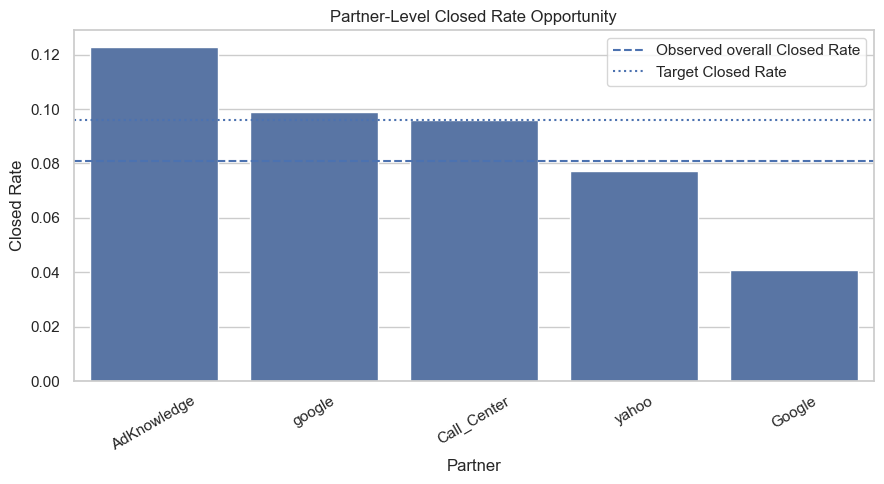

In [12]:
partner_chart = partner_opportunity.copy()

plt.figure(figsize=(9, 5))
sns.barplot(data=partner_chart, x="Partner", y="ClosedRate")
plt.axhline(observed_closed_rate, linestyle="--", label="Observed overall Closed Rate")
plt.axhline(target_closed_rate, linestyle=":", label="Target Closed Rate")
plt.title("Partner-Level Closed Rate Opportunity")
plt.xlabel("Partner")
plt.ylabel("Closed Rate")
plt.xticks(rotation=30)
plt.legend()
plt.tight_layout()
plt.show()

### Interpretation

- The higher-volume partners show meaningful differences in observed Closed Rate.
- `AdKnowledge` has a Closed Rate of approximately **12.3%**, above both the observed overall rate and the 9.6% target. `google` is also above the overall baseline at approximately **9.9%**, although only slightly above the target.
- These results indicate that acquisition source may provide an opportunity for improving the overall lead mix.
- However, the current volume of each partner is important. A high-performing partner with relatively little volume cannot by itself explain or necessarily deliver a large improvement in the overall Closed Rate.
- The separate `google` and `Google` categories should also be investigated because inconsistent naming could fragment the same acquisition source into multiple groups.

## 7. Widget Opportunities

WidgetName represents the form-ad creative shown to the consumer. The assignment specifically asks whether widget configuration is associated with lead quality.

Here, the focus is on widgets with sufficient volume so that very small samples do not dominate the opportunity analysis.

In [13]:
widget_opportunity = build_segment_opportunity(df, "WidgetName", min_leads=50)
widget_opportunity

,WidgetName,TotalLeads,ClosedLeads,ClosedRate,LeadShare,RateLiftVsBaseline
2,w-300250-DebtReduction1-1DC-CreditSolutions,77,12,0.1558,0.0255,0.0747
1,w-300250-DebtReduction1-1DC-BlueMeter,92,13,0.1413,0.0305,0.0602
3,w-300250-DebtReduction1-1DC-Head2,89,11,0.1236,0.0295,0.0425
0,w-300250-DebtReduction1-1DC,348,34,0.0977,0.1152,0.0166
8,w-302252-DebtReduction1-1DC,272,23,0.0846,0.0900,0.0035
7,w-300250-DebtReduction1-2DC-CreditSolutions,75,6,0.0800,0.0248,-0.0011
13,w-302252-DebtReduction1-1DC-yellowarrow-dark,135,10,0.0741,0.0447,-0.0070
9,w-302252-DebtReduction1-1DC-CreditSolutions,1054,76,0.0721,0.3489,-0.0090
10,w-302252-DebtReduction1-1DC-white,430,31,0.0721,0.1423,-0.0090
6,w-300250-DebtReduction1-2DC-BlueMeter,87,6,0.0690,0.0288,-0.0121


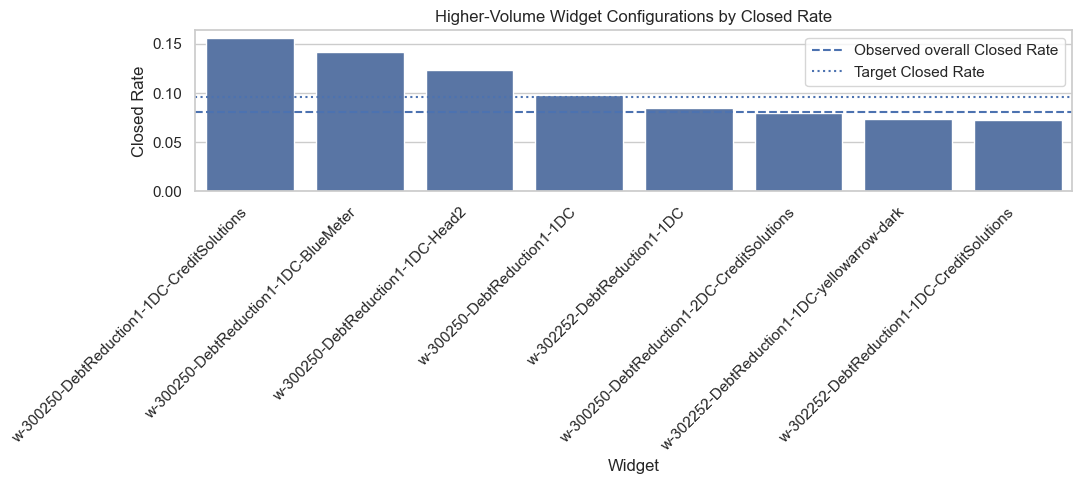

In [14]:
top_widget_opportunity = widget_opportunity.head(8)

plt.figure(figsize=(11, 5))
sns.barplot(data=top_widget_opportunity, x="WidgetName", y="ClosedRate")
plt.axhline( observed_closed_rate, linestyle="--", label="Observed overall Closed Rate")
plt.axhline(target_closed_rate, linestyle=":", label="Target Closed Rate")
plt.title("Higher-Volume Widget Configurations by Closed Rate")
plt.xlabel("Widget")
plt.ylabel("Closed Rate")
plt.xticks(rotation=45, ha="right")
plt.legend()
plt.tight_layout()
plt.show()

### Interpretation

- Several widget configurations have observed Closed Rates above the overall baseline.
- For example, `300250-CreditSolutions` records a Closed Rate of approximately **15.6%**, while `300250-BlueMeter` records approximately **14.1%**. These rates are materially above the overall observed Closed Rate of 8.11%.
- At the same time, these widgets account for relatively small portions of the total lead volume. Therefore, simply identifying a high-performing widget does not establish that switching all traffic to that widget would produce the same performance.
- The results do, however, provide a reasonable basis for controlled testing of higher-performing creative configurations.

## 8. Debt-Level Opportunities

- Debt level represents a characteristic of the consumer submitting the lead.
- The objective here is not to assume that higher or lower debt causes better lead quality, but to identify whether particular debt segments have sufficiently different observed Closed Rates to warrant further investigation.

In [15]:
debt_opportunity = build_segment_opportunity(df, "DebtLevel", min_leads=50)
debt_opportunity

,DebtLevel,TotalLeads,ClosedLeads,ClosedRate,LeadShare,RateLiftVsBaseline
5,70001-90000,131,18,0.1374,0.0434,0.0563
0,10001-15000,291,34,0.1168,0.0963,0.0357
8,90000-100000,90,9,0.1000,0.0298,0.0189
4,50001-70000,245,22,0.0898,0.0811,0.0087
2,20001-30000,456,40,0.0877,0.1509,0.0066
1,15001-20000,408,35,0.0858,0.1351,0.0047
3,30001-50000,496,39,0.0786,0.1642,-0.0025
7,7500-15000,271,19,0.0701,0.0897,-0.0110
6,7500-10000,442,22,0.0498,0.1463,-0.0313
9,More_than_100000,191,7,0.0366,0.0632,-0.0444


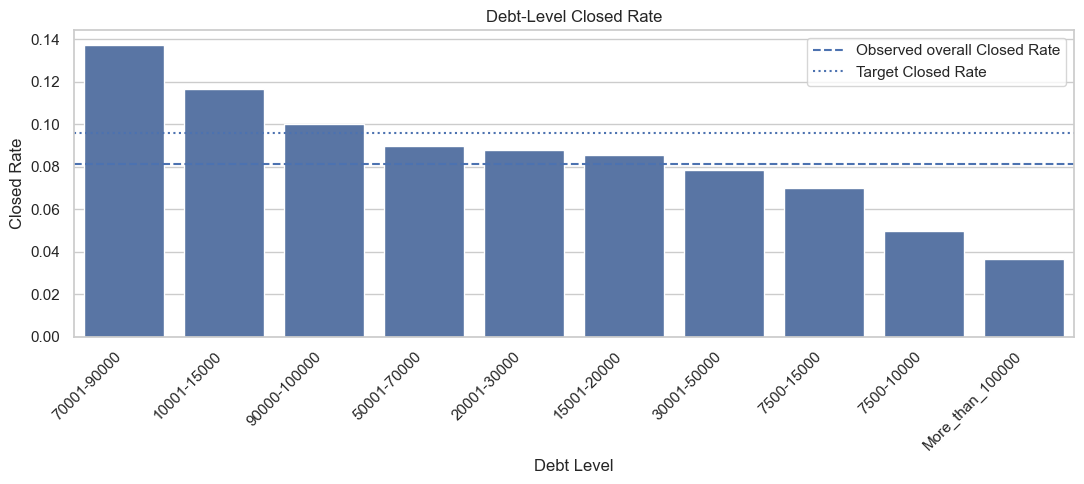

In [16]:
plt.figure(figsize=(11, 5))
sns.barplot(data=debt_opportunity, x="DebtLevel", y="ClosedRate")
plt.axhline(observed_closed_rate, linestyle="--", label="Observed overall Closed Rate")
plt.axhline(target_closed_rate, linestyle=":", label="Target Closed Rate")
plt.title("Debt-Level Closed Rate")
plt.xlabel("Debt Level")
plt.ylabel("Closed Rate")
plt.xticks(rotation=45, ha="right")
plt.legend()
plt.tight_layout()
plt.show()

### Interpretation

- Debt-level segments also show variation in observed Closed Rate.
- The `70001-90000` segment records a Closed Rate of approximately **13.7%**, while `10001-15000` records approximately **11.7%**. Both are above the 9.6% target.
- However, the relationship is not monotonic across debt levels. For example, the `More_than_100000` segment has a much lower observed Closed Rate.
- This suggests that debt level may contain useful segmentation information, but the results do not support a simple rule that increasing or decreasing debt level will consistently improve lead quality.

## 9. Scenario Analysis

- The next analysis translates the segment differences into simple mix-shift scenarios.
- For each higher-quality segment, the scenario assumes that the selected segment retains its observed Closed Rate while the remainder of the lead population performs at the current overall Closed Rate.
- This is a simplified sensitivity analysis rather than a forecast. It does not account for selection effects, overlap between segments, or performance changes that could occur when traffic volume is increased.

In [17]:
def calculate_mix_shift_scenario(
    segment_name,
    segment_leads,
    segment_rate,
    baseline_rate=observed_closed_rate,
    target_rate=target_closed_rate,
    total_leads=total_leads
):
    current_share = segment_leads / total_leads

    if segment_rate <= baseline_rate:
        required_share = np.nan
        additional_share = np.nan
        additional_leads = np.nan
    else:
        required_share = (
            (target_rate - baseline_rate)
            / (segment_rate - baseline_rate)
        )

        additional_share = max(
            required_share - current_share,
            0
        )

        additional_leads = (
            additional_share * total_leads
        )

    return {
        "Segment": segment_name,
        "SegmentLeads": segment_leads,
        "CurrentShare": current_share,
        "SegmentClosedRate": segment_rate,
        "RequiredShareAtTarget": required_share,
        "AdditionalShareNeeded": additional_share,
        "ApproxAdditionalLeads": additional_leads
    }

In [18]:
scenario_rows = []

# Partner example
for _, row in partner_opportunity.head(3).iterrows():
    scenario_rows.append(
        calculate_mix_shift_scenario(
            row["Partner"],
            row["TotalLeads"],
            row["ClosedRate"]
        )
    )

# Widget examples
for _, row in widget_opportunity.head(3).iterrows():
    scenario_rows.append(
        calculate_mix_shift_scenario(
            row["WidgetName"],
            row["TotalLeads"],
            row["ClosedRate"]
        )
    )

# Debt-level examples
for _, row in debt_opportunity.head(3).iterrows():
    scenario_rows.append(
        calculate_mix_shift_scenario(
            row["DebtLevel"],
            row["TotalLeads"],
            row["ClosedRate"]
        )
    )

scenario_analysis = pd.DataFrame(scenario_rows)

scenario_analysis

,Segment,SegmentLeads,CurrentShare,SegmentClosedRate,RequiredShareAtTarget,AdditionalShareNeeded,ApproxAdditionalLeads
0,AdKnowledge,171,0.0566,0.1228,0.3573,0.3007,908.3122
1,google,979,0.3241,0.0991,0.8287,0.5046,"1,524.4312"
2,Call_Center,271,0.0897,0.0959,1.0040,0.9143,"2,762.0174"
3,w-300250-DebtReduction1-1DC-CreditSolutions,77,0.0255,0.1558,0.1994,0.1739,525.2596
4,w-300250-DebtReduction1-1DC-BlueMeter,92,0.0305,0.1413,0.2475,0.2170,655.7073
5,w-300250-DebtReduction1-1DC-Head2,89,0.0295,0.1236,0.3506,0.3212,970.2864
6,70001-90000,131,0.0434,0.1374,0.2646,0.2213,668.4941
7,10001-15000,291,0.0963,0.1168,0.4169,0.3206,968.5583
8,90000-100000,90,0.0298,0.1000,0.7884,0.7586,"2,291.6696"


In [19]:
scenario_analysis["RequiredShareAtTarget"] = (
    scenario_analysis["RequiredShareAtTarget"]
    .replace([np.inf, -np.inf], np.nan)
)

scenario_analysis["AdditionalShareNeeded"] = (
    scenario_analysis["AdditionalShareNeeded"]
    .replace([np.inf, -np.inf], np.nan)
)

scenario_analysis[
    [
        "Segment",
        "SegmentLeads",
        "CurrentShare",
        "SegmentClosedRate",
        "RequiredShareAtTarget",
        "AdditionalShareNeeded",
        "ApproxAdditionalLeads"
    ]
]

,Segment,SegmentLeads,CurrentShare,SegmentClosedRate,RequiredShareAtTarget,AdditionalShareNeeded,ApproxAdditionalLeads
0,AdKnowledge,171,0.0566,0.1228,0.3573,0.3007,908.3122
1,google,979,0.3241,0.0991,0.8287,0.5046,"1,524.4312"
2,Call_Center,271,0.0897,0.0959,1.0040,0.9143,"2,762.0174"
3,w-300250-DebtReduction1-1DC-CreditSolutions,77,0.0255,0.1558,0.1994,0.1739,525.2596
4,w-300250-DebtReduction1-1DC-BlueMeter,92,0.0305,0.1413,0.2475,0.2170,655.7073
5,w-300250-DebtReduction1-1DC-Head2,89,0.0295,0.1236,0.3506,0.3212,970.2864
6,70001-90000,131,0.0434,0.1374,0.2646,0.2213,668.4941
7,10001-15000,291,0.0963,0.1168,0.4169,0.3206,968.5583
8,90000-100000,90,0.0298,0.1000,0.7884,0.7586,"2,291.6696"


### Interpretation

- The mix-shift analysis illustrates an important constraint: **having a high-performing segment does not automatically mean that it can generate the required overall improvement.**
- For example, `AdKnowledge` has an observed Closed Rate of approximately 12.3%, which is above the 9.6% target. Under the simplified scenario, however, a substantially larger share of total leads would need to come from this segment to move the overall rate from 8.11% to 9.6%.
- The same principle applies to higher-performing widgets and debt segments. Their current performance creates an opportunity, but their existing lead volumes are relatively limited.
- This means that the opportunity is more realistically about **incrementally shifting traffic toward higher-quality sources and configurations**, rather than assuming that one existing segment can simply be scaled to the entire lead population.

## 10. Illustrative 10% Mix-Shift

- To make the opportunity more concrete, the following scenario assumes that **10% of the total lead mix** could be shifted toward a selected higher-performing segment while the remaining 90% performs at the current overall Closed Rate.
- This is intentionally a sensitivity analysis rather than a prediction of actual future performance.

In [20]:
def mix_shift_rate(
    segment_rate,
    shift_share,
    baseline_rate=observed_closed_rate
):
    return (shift_share * segment_rate + (1 - shift_share) * baseline_rate)

selected_segments = []

for _, row in partner_opportunity.head(2).iterrows():
    selected_segments.append(
        {
            "Segment": f"Partner: {row['Partner']}",
            "ClosedRate": row["ClosedRate"]
        }
    )

for _, row in widget_opportunity.head(2).iterrows():
    selected_segments.append(
        {
            "Segment": f"Widget: {row['WidgetName']}",
            "ClosedRate": row["ClosedRate"]
        }
    )

for _, row in debt_opportunity.head(2).iterrows():
    selected_segments.append(
        {
            "Segment": f"Debt: {row['DebtLevel']}",
            "ClosedRate": row["ClosedRate"]
        }
    )

In [21]:
mix_shift_results = pd.DataFrame(selected_segments)

mix_shift_results["RateAfter10PctShift"] = (mix_shift_results["ClosedRate"].apply(lambda x: mix_shift_rate(x, 0.10)))
mix_shift_results["LiftVsCurrent"] = (mix_shift_results["RateAfter10PctShift"] - observed_closed_rate)
mix_shift_results

,Segment,ClosedRate,RateAfter10PctShift,LiftVsCurrent
0,Partner: AdKnowledge,0.1228,0.0853,0.0042
1,Partner: google,0.0991,0.0829,0.0018
2,Widget: w-300250-DebtReduction1-1DC-CreditSolu...,0.1558,0.0886,0.0075
3,Widget: w-300250-DebtReduction1-1DC-BlueMeter,0.1413,0.0871,0.0060
4,Debt: 70001-90000,0.1374,0.0867,0.0056
5,Debt: 10001-15000,0.1168,0.0847,0.0036


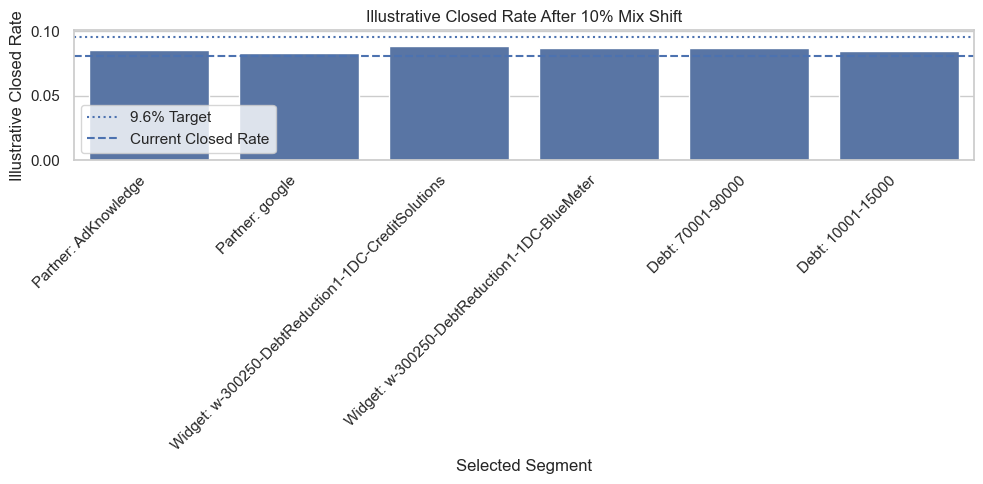

In [22]:
plt.figure(figsize=(10, 5))
sns.barplot(data=mix_shift_results, x="Segment", y="RateAfter10PctShift")
plt.axhline(target_closed_rate, linestyle=":", label="9.6% Target")
plt.axhline(observed_closed_rate, linestyle="--", label="Current Closed Rate")
plt.title("Illustrative Closed Rate After 10% Mix Shift")
plt.xlabel("Selected Segment")
plt.ylabel("Illustrative Closed Rate")
plt.xticks(rotation=45, ha="right")
plt.legend()
plt.tight_layout()
plt.show()

### Interpretation

- A 10% mix shift toward higher-performing segments improves the modeled Closed Rate, but the result depends strongly on the segment's observed performance.
- The scenario demonstrates that even relatively large differences in segment-level Closed Rate may not be sufficient to immediately reach the 9.6% target when the higher-performing segment represents only a small portion of the existing lead mix.
- This supports a gradual optimization strategy focused on testing and reallocating incremental traffic rather than assuming that the entire target can be achieved through a single segment.

## 11. Potential Quality Improvement Opportunities

- The segment and scenario analysis points to several areas where lead quality could potentially be improved.
- These opportunities are based on observed differences in the historical dataset. They should be validated through controlled testing before being treated as expected improvements.

### 1. Test Higher-Performing Widget Configurations

- Several widget configurations have materially higher observed Closed Rates than the overall baseline.
- Rather than replacing all existing creatives immediately, higher-performing widgets could be tested against current configurations while monitoring Closed Rate and lead volume.
- The objective should be to determine whether the observed difference persists when traffic is allocated prospectively.

### 2. Investigate Partner-Level Quality Differences

- Partner-level performance shows some of the clearest differences among higher-volume acquisition sources.
- Higher-performing sources can be investigated for their traffic composition, targeting, search intent, and landing-page experience. Lower-performing sources should also be reviewed to understand whether traffic quality can be improved or whether spend should be reallocated.
- The `google` versus `Google` naming inconsistency should be resolved before making detailed source-level decisions.

### 3. Use Debt Level for Traffic and Lead Segmentation

- Debt level shows meaningful differences in observed Closed Rate, including several segments above the 9.6% target.
- Rather than assuming that debt level itself causes quality differences, it can be used as a segmentation variable to understand which types of consumers are more likely to become customers.

### 4. Combine Segment Signals

- The strongest opportunity may not come from any single variable.
- For example, a particular combination of acquisition partner, widget configuration, and consumer characteristics may produce a higher-quality lead population than any one dimension considered independently.
- A follow-up analysis using multiple variables together would help determine whether these effects remain after accounting for the composition of the traffic.

### 5. Validate Through Controlled Testing

- Historical segment differences do not establish causality.
- The most practical next step would be controlled tests in which traffic is deliberately allocated between existing and proposed configurations, with Closed Rate measured as the primary outcome.

## 12. Recommended Actions

Based on the observed segment differences and the scenario analysis, the following actions would provide a practical path toward testing the 9.6% Closed Rate target.

1. **Prioritize controlled testing of higher-performing widgets.**  
   Several widget configurations show substantially higher historical Closed Rates and provide a direct opportunity to test whether creative/form differences affect lead quality.

2. **Review acquisition partner performance and traffic composition.**  
   Partner-level differences are substantial enough to warrant investigation, particularly among sources with meaningful lead volume.

3. **Investigate the characteristics of higher-quality debt segments.**  
   Debt level should be used as a segmentation signal rather than as a standalone causal explanation.

4. **Clean and standardize acquisition-source naming.**  
   The separate `google` and `Google` categories should be investigated before making source-level allocation decisions.

5. **Run controlled allocation tests before scaling.**  
   Historical performance should be validated prospectively rather than assuming that a high-performing segment will maintain its observed rate at higher volume.

6. **Track the absolute number of Closed leads as well as Closed Rate.**  
   The target requires approximately 46 additional Closed leads at the current volume, so both rate improvement and total incremental conversions should be monitored.

## Overall Findings & Conclusion

- The opportunity analysis starts from an observed Closed Rate of **8.11%** across **3,021 leads**. The advertiser's target is **9.6%**, creating a gap of approximately **1.49 percentage points**.
- At the existing lead volume, reaching a 9.6% Closed Rate would require at least **291 Closed leads**, compared with the **245 Closed leads** currently observed. This represents approximately **46 additional Closed leads** without increasing the total number of leads.
- The segment analysis shows that several parts of the lead mix perform above the overall baseline. Partner, widget configuration, and debt level each contain segments with observed Closed Rates above 9.6%.
- However, the analysis also shows why simply identifying a high-performing segment is not sufficient. Several of these segments represent relatively small portions of the overall lead population. A mix-shift scenario indicates that a substantial increase in the share of higher-quality traffic would be required to move the overall Closed Rate toward the target.
- This makes the opportunity more appropriately viewed as a **traffic and lead-mix optimization problem** rather than a single-variable solution.

### Key Opportunities

- **Widget configuration** provides a direct testing opportunity. Several widgets have materially higher observed Closed Rates than the overall baseline, making them suitable candidates for controlled creative and form experiments.
- **Partner performance** also shows meaningful differences among higher-volume acquisition sources. This suggests that traffic source and traffic composition should be investigated before increasing or decreasing allocation.
- **Debt level** provides another useful segmentation signal. Certain debt ranges show substantially higher observed Closed Rates, although the relationship is not monotonic and should not be interpreted as a causal effect.
- The analysis also identifies a data-quality consideration in acquisition reporting: `google` and `Google` appear as separate partner categories. Standardizing this naming would make future source-level analysis more reliable.

### Economic Scenario

- The assignment specifies a move from **$30 to $33 CPL** alongside a target improvement from **8.0% to 9.6% Closed Rate**.
- The quality target represents a **20% relative improvement**, because: **8.0% × 1.20 = 9.6%**
- However, the stated CPL values represent a **10% increase**, because: **($33 - $30) / $30 = 10%**
  
- The analysis therefore preserves the assignment's explicit values of **$30, $33, 8.0%, and 9.6%** rather than silently changing the scenario.

### Overall Conclusion

- The historical data contains several potential avenues for improving lead quality, particularly through **widget testing, partner-level traffic optimization, and more targeted lead segmentation**.
- At the same time, the observed segment differences should not be treated as proof that changing one variable will produce a 20% improvement in lead quality. The data is observational, segment sizes differ substantially, and several fields contain missing information.
- The clearest next step is therefore to use the historical findings to define **controlled tests**, allocate incremental traffic toward promising segments, and measure whether the resulting Closed Rate moves toward the **9.6% target** while maintaining sufficient lead volume.
- This provides a practical path from the descriptive findings in Notebook 2 to measurable optimization actions, without assuming that historical correlations will automatically translate into future performance.